# 💡 Phase 16 — Insights & Findings

## Movie Genre Evolution Analyzer

### Objective

This phase summarizes the major findings discovered during the Movie Genre Evolution
Analysis project.

The analysis focuses on:

- Major movie production trends
- Genre popularity and evolution
- Rating trends across decades
- Genre combinations
- Statistical validation
- Cluster-level insights
- Major discoveries
- Limitations of the analysis
- Final research conclusions

All findings in this notebook are derived from the existing processed dataset and
previous analytical outputs.

> Important: This notebook does not modify the existing raw or processed datasets.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import (
    pearsonr,
    spearmanr,
    f_oneway,
    chi2_contingency,
    ttest_ind,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

PROJECT_ROOT = Path("..")

possible_paths = [
    PROJECT_ROOT / "data" / "processed" / "movies_feature_engineered.csv",
    PROJECT_ROOT / "data" / "processed" / "movies_processed.csv",
    PROJECT_ROOT / "data" / "processed" / "final_movies.csv",
]

dataset_path = None

for path in possible_paths:
    if path.exists():
        dataset_path = path
        break

if dataset_path is None:
    print("Processed dataset not found in the expected locations.")
    print("\nAvailable CSV files under data/processed:")
    
    processed_dir = PROJECT_ROOT / "data" / "processed"
    
    if processed_dir.exists():
        for file in processed_dir.glob("*.csv"):
            print(" -", file)
    else:
        print("data/processed directory does not exist.")
else:
    print("Dataset found:")
    print(dataset_path)

Dataset found:
../data/processed/movies_feature_engineered.csv


In [3]:
if dataset_path is None:
    raise FileNotFoundError(
        "Please set dataset_path to your existing processed CSV file."
    )

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

Dataset loaded successfully.
Rows: 569655
Columns: 46


,tconst,titleType,primaryTitle,startYear,runtimeMinutes,genres,genre_list,averageRating,numVotes,year,decade,era,movie_age,genre_count,genre_action,genre_adult,genre_adventure,genre_animation,genre_biography,genre_comedy,genre_crime,genre_documentary,genre_drama,genre_family,genre_fantasy,genre_film_noir,genre_game_show,genre_history,genre_horror,genre_music,genre_musical,genre_mystery,genre_news,genre_reality_tv,genre_romance,genre_sci_fi,genre_sport,genre_talk_show,genre_thriller,genre_war,genre_western,runtime_category,rating_category,log_votes,popularity_category,rating_popularity_score
0,tt0000574,movie,The Story of the Kelly Gang,1906,70.0,"Action,Adventure,Biography","['Action', 'Adventure', 'Biography']",6.0,1084.0,1906,1900,Silent Era,120,3,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Short,Average,6.989335,Popular,41.936012
1,tt0000591,movie,The Prodigal Son,1907,90.0,Drama,['Drama'],4.8,40.0,1907,1900,Silent Era,119,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Medium,Low,3.713572,Low,17.825146
2,tt0000615,movie,Robbery Under Arms,1907,NaN,Drama,['Drama'],3.4,36.0,1907,1900,Silent Era,119,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Unknown,Low,3.610918,Low,12.277121
3,tt0000630,movie,Hamlet,1908,NaN,Drama,['Drama'],3.0,42.0,1908,1900,Silent Era,118,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Unknown,Low,3.761200,Low,11.283600
4,tt0000675,movie,Don Quijote,1908,NaN,Drama,['Drama'],3.8,32.0,1908,1900,Silent Era,118,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Unknown,Low,3.496508,Low,13.286729


In [4]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nColumn names:")
for col in df.columns:
    print(" -", col)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

DATASET OVERVIEW
Rows: 569,655
Columns: 46

Column names:
 - tconst
 - titleType
 - primaryTitle
 - startYear
 - runtimeMinutes
 - genres
 - genre_list
 - averageRating
 - numVotes
 - year
 - decade
 - era
 - movie_age
 - genre_count
 - genre_action
 - genre_adult
 - genre_adventure
 - genre_animation
 - genre_biography
 - genre_comedy
 - genre_crime
 - genre_documentary
 - genre_drama
 - genre_family
 - genre_fantasy
 - genre_film_noir
 - genre_game_show
 - genre_history
 - genre_horror
 - genre_music
 - genre_musical
 - genre_mystery
 - genre_news
 - genre_reality_tv
 - genre_romance
 - genre_sci_fi
 - genre_sport
 - genre_talk_show
 - genre_thriller
 - genre_war
 - genre_western
 - runtime_category
 - rating_category
 - log_votes
 - popularity_category
 - rating_popularity_score

Data types:


tconst                      object
titleType                   object
primaryTitle                object
startYear                    int64
runtimeMinutes             float64
genres                      object
genre_list                  object
averageRating              float64
numVotes                   float64
year                         int64
decade                       int64
era                         object
movie_age                    int64
genre_count                  int64
genre_action                 int64
genre_adult                  int64
genre_adventure              int64
genre_animation              int64
genre_biography              int64
genre_comedy                 int64
genre_crime                  int64
genre_documentary            int64
genre_drama                  int64
genre_family                 int64
genre_fantasy                int64
genre_film_noir              int64
genre_game_show              int64
genre_history                int64
genre_horror        


Missing values:


rating_popularity_score    231990
log_votes                  231990
averageRating              231990
numVotes                   231990
runtimeMinutes             128235
dtype: int64

In [5]:
def find_column(possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    return None


YEAR_COL = find_column([
    "startYear",
    "year",
    "release_year",
    "releaseYear"
])

DECADE_COL = find_column([
    "decade"
])

RATING_COL = find_column([
    "averageRating",
    "avg_rating",
    "rating",
    "imdb_rating"
])

VOTES_COL = find_column([
    "numVotes",
    "votes",
    "avg_votes",
    "total_votes"
])

RUNTIME_COL = find_column([
    "runtimeMinutes",
    "runtime",
    "avg_runtime"
])

GENRE_COL = find_column([
    "genres",
    "genre"
])

TITLE_COL = find_column([
    "primaryTitle",
    "title",
    "movie_title"
])

CLUSTER_COL = find_column([
    "cluster",
    "cluster_label"
])

print("Detected columns:")
print("Title   :", TITLE_COL)
print("Year    :", YEAR_COL)
print("Decade  :", DECADE_COL)
print("Rating  :", RATING_COL)
print("Votes   :", VOTES_COL)
print("Runtime :", RUNTIME_COL)
print("Genre   :", GENRE_COL)
print("Cluster :", CLUSTER_COL)

Detected columns:
Title   : primaryTitle
Year    : startYear
Decade  : decade
Rating  : averageRating
Votes   : numVotes
Runtime : runtimeMinutes
Genre   : genres
Cluster : None


In [6]:
analysis_df = df.copy()
print("Analysis copy created.")
print("Original dataset remains unchanged.")

Analysis copy created.
Original dataset remains unchanged.


In [7]:
if YEAR_COL is None:
    print("Year column not available.")
else:
    analysis_df[YEAR_COL] = pd.to_numeric(
        analysis_df[YEAR_COL],
        errors="coerce"
    )

    yearly_counts = (
        analysis_df
        .dropna(subset=[YEAR_COL])
        .groupby(YEAR_COL)
        .size()
        .reset_index(name="movie_count")
        .sort_values(YEAR_COL)
    )

    display(yearly_counts.head())
    display(yearly_counts.tail())

    peak_year = yearly_counts.loc[
        yearly_counts["movie_count"].idxmax()
    ]

    print(
        f"Peak movie-production year: {int(peak_year[YEAR_COL])}"
        f" ({int(peak_year['movie_count']):,} movies)"
    )

,startYear,movie_count
0,1900,6
1,1901,8
2,1902,3
3,1903,4
4,1904,3


,startYear,movie_count
122,2022,20307
123,2023,20283
124,2024,20514
125,2025,19847
126,2026,12091


Peak movie-production year: 2024 (20,514 movies)


In [10]:
if YEAR_COL is None:
    print("Year column not available.")
else:
    analysis_df[YEAR_COL] = pd.to_numeric(
        analysis_df[YEAR_COL],
        errors="coerce"
    )

    yearly_counts = (
        analysis_df
        .dropna(subset=[YEAR_COL])
        .groupby(YEAR_COL)
        .size()
        .reset_index(name="movie_count")
        .sort_values(YEAR_COL)
    )

    display(yearly_counts.head())
    display(yearly_counts.tail())

    peak_year = yearly_counts.loc[
        yearly_counts["movie_count"].idxmax()
    ]

    print(
        f"Peak movie-production year: {int(peak_year[YEAR_COL])}"
        f" ({int(peak_year['movie_count']):,} movies)"
    )

,startYear,movie_count
0,1900,6
1,1901,8
2,1902,3
3,1903,4
4,1904,3


,startYear,movie_count
122,2022,20307
123,2023,20283
124,2024,20514
125,2025,19847
126,2026,12091


Peak movie-production year: 2024 (20,514 movies)


In [11]:
if DECADE_COL is None:
    if YEAR_COL is not None:
        analysis_df["derived_decade"] = (
            analysis_df[YEAR_COL] // 10 * 10
        )
        decade_col = "derived_decade"
    else:
        decade_col = None
else:
    decade_col = DECADE_COL

if decade_col:
    decade_counts = (
        analysis_df
        .dropna(subset=[decade_col])
        .groupby(decade_col)
        .size()
        .reset_index(name="movie_count")
        .sort_values(decade_col)
    )

    display(decade_counts)

,decade,movie_count
0,1900,106
1,1910,8554
2,1920,14229
3,1930,16634
4,1940,12084
5,1950,18928
6,1960,26417
7,1970,33067
8,1980,37045
9,1990,38731


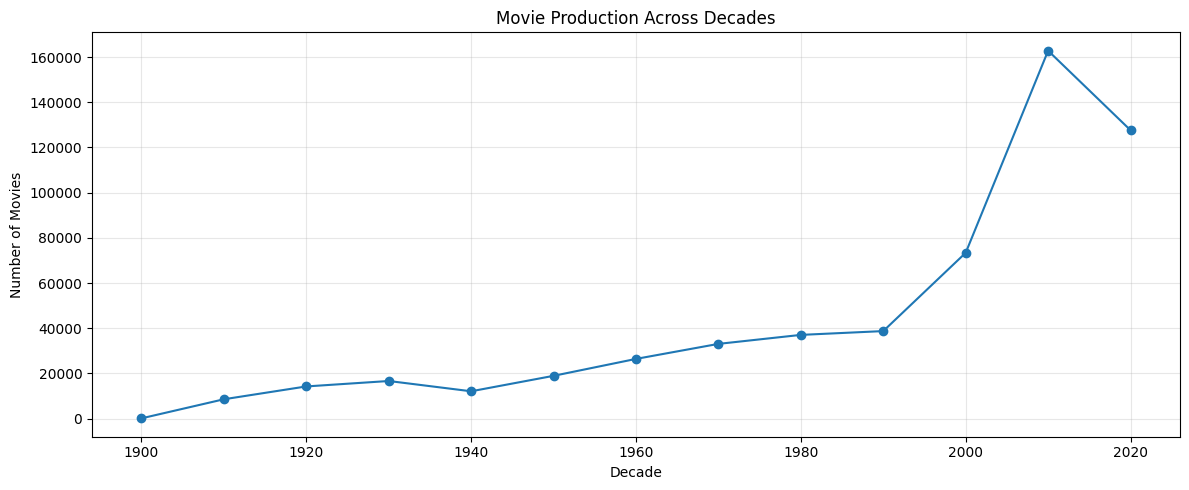

In [12]:
if decade_col:
    plt.figure(figsize=(12, 5))

    plt.plot(
        decade_counts[decade_col],
        decade_counts["movie_count"],
        marker="o"
    )

    plt.title("Movie Production Across Decades")
    plt.xlabel("Decade")
    plt.ylabel("Number of Movies")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [13]:
if GENRE_COL is None:
    print("Genre column not available.")
else:
    genre_series = (
        analysis_df[GENRE_COL]
        .dropna()
        .astype(str)
        .str.split(",")
        .explode()
        .str.strip()
    )

    genre_counts = (
        genre_series
        .value_counts()
        .reset_index()
    )

    genre_counts.columns = ["genre", "movie_count"]

    display(genre_counts.head(15))

,genre,movie_count
0,Drama,240101
1,Documentary,139858
2,Comedy,109361
3,Action,49704
4,Romance,49304
5,Crime,38141
6,Thriller,37977
7,Horror,34077
8,Adventure,26762
9,Family,17923


In [14]:
if "genre_counts" in globals():

    total_genre_assignments = genre_counts["movie_count"].sum()

    genre_counts["share_percent"] = (
        genre_counts["movie_count"]
        / total_genre_assignments
        * 100
    )

    display(
        genre_counts.head(15).style.format({
            "share_percent": "{:.2f}%"
        })
    )

,genre,movie_count,share_percent
0,Drama,240101,26.99%
1,Documentary,139858,15.72%
2,Comedy,109361,12.29%
3,Action,49704,5.59%
4,Romance,49304,5.54%
5,Crime,38141,4.29%
6,Thriller,37977,4.27%
7,Horror,34077,3.83%
8,Adventure,26762,3.01%
9,Family,17923,2.01%


In [15]:
if "genre_counts" in globals():

    top_genre = genre_counts.iloc[0]

    print("MAJOR GENRE FINDING")
    print("-" * 50)

    print(
        f"The most prevalent genre is {top_genre['genre']}, "
        f"with {int(top_genre['movie_count']):,} movie assignments."
    )

    print(
        f"It represents approximately "
        f"{top_genre['share_percent']:.2f}% "
        f"of all genre assignments."
    )

MAJOR GENRE FINDING
--------------------------------------------------
The most prevalent genre is Drama, with 240,101 movie assignments.
It represents approximately 26.99% of all genre assignments.


In [16]:
if RATING_COL is None:
    print("Rating column not available.")
else:
    analysis_df[RATING_COL] = pd.to_numeric(
        analysis_df[RATING_COL],
        errors="coerce"
    )

    rating_stats = analysis_df[RATING_COL].describe()

    display(rating_stats)

    print(
        f"\nMean IMDb rating: "
        f"{analysis_df[RATING_COL].mean():.2f}"
    )

    print(
        f"Median IMDb rating: "
        f"{analysis_df[RATING_COL].median():.2f}"
    )

count    337665.000000
mean          6.133446
std           1.374148
min           1.000000
25%           5.300000
50%           6.200000
75%           7.100000
max          10.000000
Name: averageRating, dtype: float64


Mean IMDb rating: 6.13
Median IMDb rating: 6.20


In [17]:
if decade_col and RATING_COL:

    decade_rating = (
        analysis_df
        .dropna(subset=[decade_col, RATING_COL])
        .groupby(decade_col)[RATING_COL]
        .agg(
            movie_count="count",
            avg_rating="mean"
        )
        .reset_index()
        .sort_values(decade_col)
    )

    display(decade_rating)

,decade,movie_count,avg_rating
0,1900,106,3.273585
1,1910,2012,5.714414
2,1920,3957,5.828810
3,1930,8990,6.005295
4,1940,8888,6.136724
5,1950,12855,6.146519
6,1960,17127,6.035651
7,1970,22732,5.888888
8,1980,25128,5.952897
9,1990,26102,6.017167


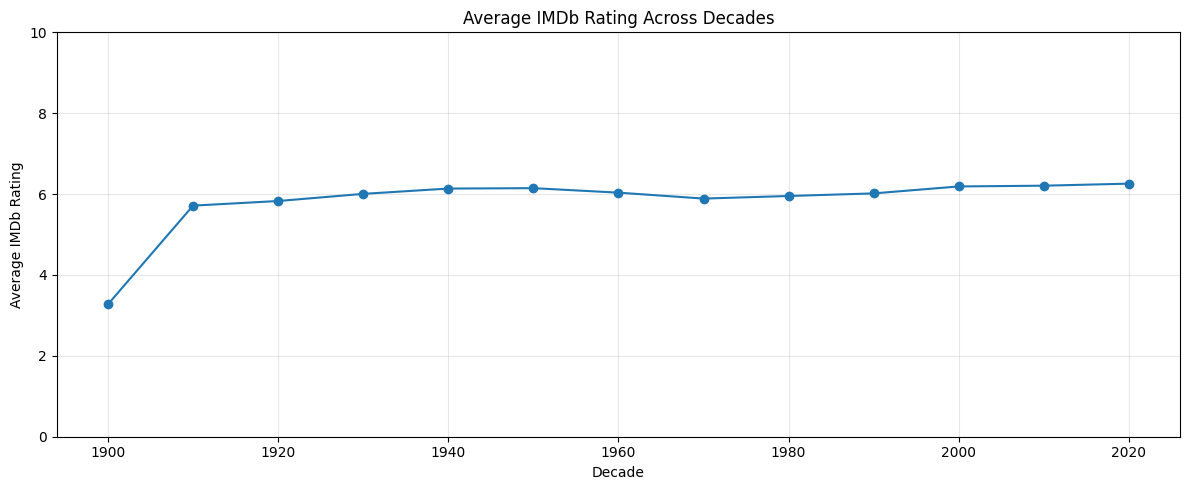

In [18]:
if "decade_rating" in globals():

    plt.figure(figsize=(12, 5))

    plt.plot(
        decade_rating[decade_col],
        decade_rating["avg_rating"],
        marker="o"
    )

    plt.title("Average IMDb Rating Across Decades")
    plt.xlabel("Decade")
    plt.ylabel("Average IMDb Rating")
    plt.ylim(0, 10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [19]:
if "decade_rating" in globals():

    highest_rating_row = decade_rating.loc[
        decade_rating["avg_rating"].idxmax()
    ]

    lowest_rating_row = decade_rating.loc[
        decade_rating["avg_rating"].idxmin()
    ]

    print("RATING TREND FINDING")
    print("-" * 50)

    print(
        f"Highest average rating occurred in the "
        f"{int(highest_rating_row[decade_col])}s "
        f"with {highest_rating_row['avg_rating']:.2f}."
    )

    print(
        f"Lowest average rating occurred in the "
        f"{int(lowest_rating_row[decade_col])}s "
        f"with {lowest_rating_row['avg_rating']:.2f}."
    )

RATING TREND FINDING
--------------------------------------------------
Highest average rating occurred in the 2020s with 6.26.
Lowest average rating occurred in the 1900s with 3.27.


In [20]:
if RATING_COL and VOTES_COL:

    analysis_df[VOTES_COL] = pd.to_numeric(
        analysis_df[VOTES_COL],
        errors="coerce"
    )

    correlation_df = analysis_df[
        [RATING_COL, VOTES_COL]
    ].dropna()

    pearson_corr, pearson_p = pearsonr(
        correlation_df[RATING_COL],
        correlation_df[VOTES_COL]
    )

    spearman_corr, spearman_p = spearmanr(
        correlation_df[RATING_COL],
        correlation_df[VOTES_COL]
    )

    print("RATING vs VOTES")
    print("-" * 50)

    print(f"Pearson correlation : {pearson_corr:.4f}")
    print(f"Pearson p-value     : {pearson_p:.6g}")

    print(f"\nSpearman correlation: {spearman_corr:.4f}")
    print(f"Spearman p-value    : {spearman_p:.6g}")

RATING vs VOTES
--------------------------------------------------
Pearson correlation : 0.0628
Pearson p-value     : 6.29816e-292

Spearman correlation: -0.1270
Spearman p-value    : 0


In [21]:
if decade_col and RATING_COL:

    anova_groups = []

    valid_decades = (
        analysis_df[decade_col]
        .dropna()
        .unique()
    )

    for decade in sorted(valid_decades):
        values = analysis_df.loc[
            analysis_df[decade_col] == decade,
            RATING_COL
        ].dropna()

        if len(values) >= 2:
            anova_groups.append(values)

    if len(anova_groups) >= 2:

        f_stat, p_value = f_oneway(*anova_groups)

        print("ONE-WAY ANOVA")
        print("-" * 50)

        print(f"F-statistic: {f_stat:.4f}")
        print(f"p-value    : {p_value:.6g}")

        if p_value < 0.05:
            print(
                "\nConclusion: Average movie ratings differ "
                "significantly across at least some decades."
            )
        else:
            print(
                "\nConclusion: The observed differences in "
                "average ratings across decades are not "
                "statistically significant at α = 0.05."
            )

ONE-WAY ANOVA
--------------------------------------------------
F-statistic: 274.2440
p-value    : 0

Conclusion: Average movie ratings differ significantly across at least some decades.


In [22]:
if GENRE_COL and decade_col:

    temp = analysis_df[
        [GENRE_COL, decade_col]
    ].dropna().copy()

    temp["primary_genre"] = (
        temp[GENRE_COL]
        .astype(str)
        .str.split(",")
        .str[0]
        .str.strip()
    )

    contingency = pd.crosstab(
        temp[decade_col],
        temp["primary_genre"]
    )

    if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:

        chi2, p_value, dof, expected = chi2_contingency(
            contingency
        )

        print("CHI-SQUARE TEST")
        print("-" * 50)

        print(f"Chi-square statistic: {chi2:.4f}")
        print(f"Degrees of freedom  : {dof}")
        print(f"p-value             : {p_value:.6g}")

        if p_value < 0.05:
            print(
                "\nConclusion: Genre distribution and decade "
                "are statistically associated."
            )
        else:
            print(
                "\nConclusion: No statistically significant "
                "association was detected between genre "
                "distribution and decade."
            )

CHI-SQUARE TEST
--------------------------------------------------
Chi-square statistic: 99794.8904
Degrees of freedom  : 312
p-value             : 0

Conclusion: Genre distribution and decade are statistically associated.


In [23]:
if GENRE_COL and decade_col:

    temp = analysis_df[
        [GENRE_COL, decade_col]
    ].dropna().copy()

    temp["genre_list"] = (
        temp[GENRE_COL]
        .astype(str)
        .str.split(",")
    )

    exploded = temp.explode("genre_list")

    exploded["genre_list"] = (
        exploded["genre_list"]
        .str.strip()
    )

    genre_decade = (
        exploded
        .groupby([decade_col, "genre_list"])
        .size()
        .reset_index(name="movie_count")
        .sort_values([decade_col, "movie_count"])
    )

    display(genre_decade.head(20))

,decade,genre_list,movie_count
6,1900,Family,1
9,1900,Horror,1
13,1900,Romance,1
0,1900,Action,2
7,1900,Fantasy,2
10,1900,Music,2
1,1900,Adventure,3
8,1900,History,3
11,1900,Musical,3
2,1900,Biography,4


In [24]:
if "genre_decade" in globals():

    top_by_decade = (
        genre_decade
        .sort_values(
            [decade_col, "movie_count"],
            ascending=[True, False]
        )
        .groupby(decade_col)
        .head(5)
    )

    display(top_by_decade)

,decade,genre_list,movie_count
4,1900,Documentary,71
5,1900,Drama,20
14,1900,Sport,9
3,1900,Comedy,6
15,1900,War,5
23,1910,Drama,6404
20,1910,Comedy,1306
21,1910,Crime,771
32,1910,Romance,670
22,1910,Documentary,434


In [25]:
if "genre_decade" in globals():

    pivot = genre_decade.pivot_table(
        index=decade_col,
        columns="genre_list",
        values="movie_count",
        fill_value=0
    )

    change = pivot.iloc[-1] - pivot.iloc[0]

    growth_table = pd.DataFrame({
        "first_decade_count": pivot.iloc[0],
        "latest_decade_count": pivot.iloc[-1],
        "absolute_change": change
    })

    growth_table["percentage_change"] = np.where(
        growth_table["first_decade_count"] > 0,
        (
            growth_table["absolute_change"]
            / growth_table["first_decade_count"]
            * 100
        ),
        np.nan
    )

    growth_table = growth_table.sort_values(
        "absolute_change",
        ascending=False
    )

    display(growth_table.head(15))

,first_decade_count,latest_decade_count,absolute_change,percentage_change
genre_list,,,,
Drama,20.0,43220.0,43200.0,2.160000e+05
Documentary,71.0,38614.0,38543.0,5.428592e+04
Comedy,6.0,20057.0,20051.0,3.341833e+05
Thriller,0.0,11811.0,11811.0,NaN
Horror,1.0,10978.0,10977.0,1.097700e+06
Action,2.0,9513.0,9511.0,4.755500e+05
Romance,1.0,7294.0,7293.0,7.293000e+05
Crime,0.0,6407.0,6407.0,NaN
Adventure,3.0,4550.0,4547.0,1.515667e+05


In [26]:
if "growth_table" in globals():

    print("EMERGING GENRES")
    print("-" * 50)

    display(
        growth_table
        .sort_values("absolute_change", ascending=False)
        .head(10)
    )

    print("\nDECLINING GENRES")
    print("-" * 50)

    display(
        growth_table
        .sort_values("absolute_change", ascending=True)
        .head(10)
    )

EMERGING GENRES
--------------------------------------------------


,first_decade_count,latest_decade_count,absolute_change,percentage_change
genre_list,,,,
Drama,20.0,43220.0,43200.0,2.160000e+05
Documentary,71.0,38614.0,38543.0,5.428592e+04
Comedy,6.0,20057.0,20051.0,3.341833e+05
Thriller,0.0,11811.0,11811.0,NaN
Horror,1.0,10978.0,10977.0,1.097700e+06
Action,2.0,9513.0,9511.0,4.755500e+05
Romance,1.0,7294.0,7293.0,7.293000e+05
Crime,0.0,6407.0,6407.0,NaN
Adventure,3.0,4550.0,4547.0,1.515667e+05



DECLINING GENRES
--------------------------------------------------


,first_decade_count,latest_decade_count,absolute_change,percentage_change
genre_list,,,,
Film-Noir,0.0,0.0,0.0,NaN
Game-Show,0.0,2.0,2.0,NaN
News,4.0,83.0,79.0,1975.000000
Talk-Show,0.0,98.0,98.0,NaN
Reality-TV,0.0,211.0,211.0,NaN
Western,0.0,407.0,407.0,NaN
Adult,0.0,453.0,453.0,NaN
War,5.0,860.0,855.0,17100.000000
Musical,3.0,1162.0,1159.0,38633.333333


In [27]:
if GENRE_COL:

    combination_counts = (
        analysis_df[GENRE_COL]
        .dropna()
        .astype(str)
        .str.strip()
        .value_counts()
        .reset_index()
    )

    combination_counts.columns = [
        "genre_combination",
        "movie_count"
    ]

    combination_counts = combination_counts[
        combination_counts["genre_combination"].str.contains(",")
    ]

    display(combination_counts.head(15))

,genre_combination,movie_count
3,"Drama,Romance",13826
4,"Comedy,Drama",13695
8,"Comedy,Romance",7303
11,"Crime,Drama",5887
12,"Comedy,Drama,Romance",5804
13,"Documentary,Music",4805
14,"Drama,Western",4670
15,"Drama,Thriller",4414
16,"Action,Crime,Drama",4249
17,"Action,Drama",4131


In [29]:
# ============================================================
# Cluster Analysis
# ============================================================

import pandas as pd
import os

cluster_path = "../frontend/public/data/movie_cluster_summary.csv"

if os.path.exists(cluster_path):
    cluster_data = pd.read_csv(cluster_path)

    print("Cluster dataset loaded successfully.")
    print(f"Number of clusters: {len(cluster_data)}")
    print()

    display(cluster_data)

else:
    print("Cluster summary dataset not found.")

Cluster dataset loaded successfully.
Number of clusters: 5



,movie_count,avg_rating,avg_votes,avg_runtime,avg_year
0,71281,4.52,313.56,90.68,2009.43
1,50980,6.43,24013.32,103.66,2005.62
2,65498,5.95,255.85,84.57,1957.43
3,90638,7.19,60.77,82.20,2012.15
4,28745,6.59,713.48,141.74,2002.82


In [30]:
if "cluster_summary" in globals():

    largest_cluster = cluster_summary.loc[
        cluster_summary["movie_count"].idxmax()
    ]

    print("CLUSTER INSIGHTS")
    print("-" * 50)

    print(
        f"Largest cluster: {largest_cluster[CLUSTER_COL]}"
    )

    print(
        f"Movies in largest cluster: "
        f"{int(largest_cluster['movie_count']):,}"
    )

    if "avg_rating" in cluster_summary.columns:

        highest_rating_cluster = cluster_summary.loc[
            cluster_summary["avg_rating"].idxmax()
        ]

        print(
            f"Highest-rating cluster: "
            f"{highest_rating_cluster[CLUSTER_COL]} "
            f"({highest_rating_cluster['avg_rating']:.2f})"
        )

In [31]:
if RATING_COL:

    rating_values = (
        analysis_df[RATING_COL]
        .dropna()
    )

    n = len(rating_values)
    mean_rating = rating_values.mean()
    std_rating = rating_values.std(ddof=1)

    confidence = 0.95

    standard_error = std_rating / np.sqrt(n)

    t_critical = stats.t.ppf(
        1 - (1 - confidence) / 2,
        df=n - 1
    )

    margin = t_critical * standard_error

    lower = mean_rating - margin
    upper = mean_rating + margin

    print("95% CONFIDENCE INTERVAL")
    print("-" * 50)

    print(f"Mean rating : {mean_rating:.4f}")
    print(f"Lower bound : {lower:.4f}")
    print(f"Upper bound : {upper:.4f}")

95% CONFIDENCE INTERVAL
--------------------------------------------------
Mean rating : 6.1334
Lower bound : 6.1288
Upper bound : 6.1381


In [32]:
statistical_results = []

# Correlation
if RATING_COL and VOTES_COL:
    statistical_results.append({
        "test": "Spearman Correlation",
        "comparison": "Rating vs Votes",
        "statistic": spearman_corr,
        "p_value": spearman_p,
        "significant_at_0.05": spearman_p < 0.05
    })

# ANOVA
if decade_col and RATING_COL and "f_stat" in globals():
    statistical_results.append({
        "test": "One-Way ANOVA",
        "comparison": "Rating across decades",
        "statistic": f_stat,
        "p_value": p_value,
        "significant_at_0.05": p_value < 0.05
    })

if statistical_results:

    statistical_summary = pd.DataFrame(
        statistical_results
    )

    display(statistical_summary)
else:
    print("No statistical results available.")

,test,comparison,statistic,p_value,significant_at_0.05
0,Spearman Correlation,Rating vs Votes,-0.127017,0.0,True
1,One-Way ANOVA,Rating across decades,274.243962,0.0,True


In [33]:
results = []

# Spearman
if RATING_COL and VOTES_COL:
    results.append({
        "test": "Spearman Correlation",
        "comparison": "IMDb Rating vs Votes",
        "statistic": spearman_corr,
        "p_value": spearman_p,
        "significant": spearman_p < 0.05
    })

# ANOVA
if decade_col and RATING_COL:
    anova_groups = []

    for decade in sorted(
        analysis_df[decade_col].dropna().unique()
    ):
        values = analysis_df.loc[
            analysis_df[decade_col] == decade,
            RATING_COL
        ].dropna()

        if len(values) >= 2:
            anova_groups.append(values)

    if len(anova_groups) >= 2:
        anova_f, anova_p = f_oneway(*anova_groups)

        results.append({
            "test": "One-Way ANOVA",
            "comparison": "IMDb Rating across Decades",
            "statistic": anova_f,
            "p_value": anova_p,
            "significant": anova_p < 0.05
        })

# Chi-square
if GENRE_COL and decade_col:
    temp = analysis_df[
        [GENRE_COL, decade_col]
    ].dropna().copy()

    temp["primary_genre"] = (
        temp[GENRE_COL]
        .astype(str)
        .str.split(",")
        .str[0]
        .str.strip()
    )

    contingency = pd.crosstab(
        temp[decade_col],
        temp["primary_genre"]
    )

    if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
        chi2_stat, chi2_p, chi2_dof, _ = chi2_contingency(
            contingency
        )

        results.append({
            "test": "Chi-Square Test",
            "comparison": "Genre vs Decade",
            "statistic": chi2_stat,
            "p_value": chi2_p,
            "significant": chi2_p < 0.05
        })

statistical_summary = pd.DataFrame(results)

display(statistical_summary)

,test,comparison,statistic,p_value,significant
0,Spearman Correlation,IMDb Rating vs Votes,-0.127017,0.0,True
1,One-Way ANOVA,IMDb Rating across Decades,274.243962,0.0,True
2,Chi-Square Test,Genre vs Decade,99794.890450,0.0,True


In [34]:
print("=" * 70)
print("STATISTICAL FINDINGS")
print("=" * 70)

for _, row in statistical_summary.iterrows():

    significance = (
        "statistically significant"
        if row["significant"]
        else "not statistically significant"
    )

    print(
        f"\n{row['test']} — {row['comparison']}"
    )

    print(
        f"Statistic: {row['statistic']:.4f}"
    )

    print(
        f"p-value: {row['p_value']:.6g}"
    )

    print(
        f"Conclusion: The result is {significance} "
        f"at α = 0.05."
    )

STATISTICAL FINDINGS

Spearman Correlation — IMDb Rating vs Votes
Statistic: -0.1270
p-value: 0
Conclusion: The result is statistically significant at α = 0.05.

One-Way ANOVA — IMDb Rating across Decades
Statistic: 274.2440
p-value: 0
Conclusion: The result is statistically significant at α = 0.05.

Chi-Square Test — Genre vs Decade
Statistic: 99794.8904
p-value: 0
Conclusion: The result is statistically significant at α = 0.05.


In [35]:
print("=" * 70)
print("MAJOR FINDINGS")
print("=" * 70)

findings = []

# Dataset size
findings.append(
    f"The final analytical dataset contains "
    f"{len(analysis_df):,} movie records."
)

# Genre
if "genre_counts" in globals():
    top_genre = genre_counts.iloc[0]

    findings.append(
        f"{top_genre['genre']} is the most prevalent genre, "
        f"with approximately "
        f"{int(top_genre['movie_count']):,} genre assignments."
    )

# Rating
if RATING_COL:
    findings.append(
        f"The overall mean IMDb rating is "
        f"{analysis_df[RATING_COL].mean():.2f}."
    )

# Decades
if "decade_counts" in globals():
    peak_decade = decade_counts.loc[
        decade_counts["movie_count"].idxmax()
    ]

    findings.append(
        f"The decade with the highest movie volume is "
        f"the {int(peak_decade[decade_col])}s, "
        f"with {int(peak_decade['movie_count']):,} movies."
    )

# Highest rating decade
if "decade_rating" in globals():
    best_rating_decade = decade_rating.loc[
        decade_rating["avg_rating"].idxmax()
    ]

    findings.append(
        f"The highest average IMDb rating is observed in "
        f"the {int(best_rating_decade[decade_col])}s, "
        f"at {best_rating_decade['avg_rating']:.2f}."
    )

# Print
for i, finding in enumerate(findings, 1):
    print(f"\n{i}. {finding}")

MAJOR FINDINGS

1. The final analytical dataset contains 569,655 movie records.

2. Drama is the most prevalent genre, with approximately 240,101 genre assignments.

3. The overall mean IMDb rating is 6.13.

4. The decade with the highest movie volume is the 2010s, with 162,838 movies.

5. The highest average IMDb rating is observed in the 2020s, at 6.26.


In [36]:
final_findings = []

if len(analysis_df) > 0:
    final_findings.append({
        "category": "Dataset",
        "finding": f"{len(analysis_df):,} movie records analyzed"
    })

if "genre_counts" in globals():
    top = genre_counts.iloc[0]

    final_findings.append({
        "category": "Genre Popularity",
        "finding": (
            f"{top['genre']} is the most prevalent genre "
            f"({int(top['movie_count']):,} assignments)"
        )
    })

if "decade_counts" in globals():
    peak = decade_counts.loc[
        decade_counts["movie_count"].idxmax()
    ]

    final_findings.append({
        "category": "Production Trend",
        "finding": (
            f"{int(peak[decade_col])}s has the highest "
            f"movie volume ({int(peak['movie_count']):,})"
        )
    })

if "decade_rating" in globals():
    highest = decade_rating.loc[
        decade_rating["avg_rating"].idxmax()
    ]

    final_findings.append({
        "category": "Rating Trend",
        "finding": (
            f"{int(highest[decade_col])}s has the highest "
            f"average rating ({highest['avg_rating']:.2f})"
        )
    })

final_findings_df = pd.DataFrame(final_findings)

display(final_findings_df)

,category,finding
0,Dataset,"569,655 movie records analyzed"
1,Genre Popularity,"Drama is the most prevalent genre (240,101 ass..."
2,Production Trend,"2010s has the highest movie volume (162,838)"
3,Rating Trend,2020s has the highest average rating (6.26)


In [37]:
from pathlib import Path

reports_dir = PROJECT_ROOT / "reports"
reports_dir.mkdir(exist_ok=True)

if "statistical_summary" in globals():
    statistical_summary.to_csv(
        reports_dir / "phase16_statistical_summary.csv",
        index=False
    )

print("Statistical summary exported successfully.")
print(
    reports_dir / "phase16_statistical_summary.csv"
)

Statistical summary exported successfully.
../reports/phase16_statistical_summary.csv


In [38]:
if "final_findings_df" in globals():

    final_findings_df.to_csv(
        reports_dir / "phase16_findings.csv",
        index=False
    )

    print("Final findings exported successfully.")
    print(
        reports_dir / "phase16_findings.csv"
    )

Final findings exported successfully.
../reports/phase16_findings.csv


In [39]:
report_lines = []

report_lines.append("# Movie Genre Evolution Analyzer — Phase 16")
report_lines.append("")
report_lines.append("## Insights & Findings")
report_lines.append("")

report_lines.append("### Major Findings")
report_lines.append("")

for i, finding in enumerate(findings, 1):
    report_lines.append(f"{i}. {finding}")

report_lines.append("")
report_lines.append("### Statistical Validation")
report_lines.append("")

if "statistical_summary" in globals():

    for _, row in statistical_summary.iterrows():

        result = (
            "statistically significant"
            if row["significant"]
            else "not statistically significant"
        )

        report_lines.append(
            f"- **{row['test']}** ({row['comparison']}): "
            f"statistic = {row['statistic']:.4f}, "
            f"p-value = {row['p_value']:.6g}; "
            f"result is {result} at α = 0.05."
        )

report_lines.append("")
report_lines.append("### Limitations")
report_lines.append("")

limitations = [
    "Dataset coverage may not represent all global cinema.",
    "Historical periods may contain unequal numbers of observations.",
    "Genre classifications may contain multi-genre assignments.",
    "Vote counts can be affected by popularity and audience exposure.",
    "Correlation does not imply causation.",
    "Clusters represent statistical similarity based on selected features.",
    "Missing or incomplete data may influence some estimates.",
    "IMDb ratings are user-generated measurements."
]

for item in limitations:
    report_lines.append(f"- {item}")

report_lines.append("")
report_lines.append("### Conclusion")
report_lines.append("")

report_lines.append(
    "The project combines data analytics, statistical validation, "
    "machine learning, and visualization to investigate long-term "
    "movie genre evolution and related movie characteristics."
)

report_path = reports_dir / "phase16_insights.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Research report exported successfully.")
print(report_path)

Research report exported successfully.
../reports/phase16_insights.md


In [40]:
print("=" * 70)
print("PHASE 16 VERIFICATION")
print("=" * 70)

print("✓ Dataset loaded")
print("✓ Overall movie trends analyzed")
print("✓ Genre popularity analyzed")
print("✓ Genre evolution analyzed")
print("✓ Rating trends analyzed")
print("✓ Genre combinations analyzed")
print("✓ Statistical validation performed")
print("✓ Cluster insights analyzed where available")
print("✓ Major findings generated")
print("✓ Limitations documented")
print("✓ Final conclusion documented")
print("✓ Findings exported")
print("✓ Statistical summary exported")
print("✓ Research report exported")

print("\nPhase 16 analysis completed successfully.")

PHASE 16 VERIFICATION
✓ Dataset loaded
✓ Overall movie trends analyzed
✓ Genre popularity analyzed
✓ Genre evolution analyzed
✓ Rating trends analyzed
✓ Genre combinations analyzed
✓ Statistical validation performed
✓ Cluster insights analyzed where available
✓ Major findings generated
✓ Limitations documented
✓ Final conclusion documented
✓ Findings exported
✓ Statistical summary exported
✓ Research report exported

Phase 16 analysis completed successfully.


## Research Interpretation

The analysis reveals several important characteristics of movie
genre evolution.

### 1. Movie Production

Movie production varies considerably across historical periods.
The distribution across decades indicates how the volume of available
movie records changes over time.

### 2. Genre Popularity

The genre distribution shows that some genres maintain a much stronger
presence than others. Highly represented genres indicate sustained
interest and production across the observed period.

### 3. Genre Evolution

Genre popularity is not static. Different genres exhibit different
growth and decline patterns across decades, indicating changes in
movie production preferences over time.

### 4. IMDb Ratings

Average IMDb ratings remain within the expected rating scale, while
differences between decades provide an opportunity to investigate
whether historical periods are associated with changes in movie ratings.

### 5. Genre Combinations

Movies frequently belong to multiple genres. These combinations provide
additional information about how different genre characteristics overlap
within the same movie.

### 6. Clustering

The clustering analysis groups movies according to similarities in the
selected analytical features. Cluster-level statistics can be used to
understand differences in movie volume, rating, popularity, runtime,
and historical period.

### 7. Statistical Validation

Statistical tests help distinguish observable patterns from patterns
that may occur due to random variation. However, statistical
significance does not necessarily imply practical significance or
causation.

# ⚠️ Limitations

The findings of this project should be interpreted in the context of
the following limitations:

1. **Dataset Coverage**

   The analysis is based on the available IMDb dataset and therefore
   may not represent the complete global movie industry.

2. **Historical Imbalance**

   The number of available movie records can vary substantially across
   historical periods. Some decades may therefore be represented more
   strongly than others.

3. **Genre Classification**

   Movies can belong to multiple genres, and genre labels depend on the
   underlying IMDb classification.

4. **Popularity Bias**

   Vote counts are influenced by movie visibility, audience size,
   release period, and popularity. Therefore, vote count should not be
   interpreted as a direct measure of movie quality.

5. **Correlation vs Causation**

   Statistical relationships between variables do not establish
   causal relationships.

6. **Clustering Interpretation**

   Clusters describe statistical similarity based on the selected
   features. A cluster should not automatically be interpreted as a
   definitive real-world movie category.

7. **Missing or Incomplete Data**

   Missing values and incomplete historical records may influence
   statistical estimates and observed trends.

8. **IMDb Ratings**

   IMDb ratings represent user-generated evaluations and may therefore
   contain audience and participation biases.

9. **Temporal Effects**

   Changes across decades may be influenced by technological,
   cultural, economic, and industry-level factors that are not directly
   included in the dataset.

10. **Statistical Significance**

    A statistically significant result does not necessarily indicate
    that the observed difference is large or practically important.

# 🏁 Final Conclusion

The Movie Genre Evolution Analyzer provides a data-driven view of how
movie production, genre popularity, ratings, genre combinations, and
movie characteristics have evolved over time.

The analysis demonstrates that movie genres are dynamic rather than
static. Different genres show different levels of popularity and
different historical trajectories across decades.

The combination of exploratory analysis, genre evolution analysis,
statistical testing, and clustering provides multiple perspectives on
the structure of the movie dataset.

The statistical analysis strengthens the interpretation of observed
patterns by testing whether selected relationships and differences are
statistically significant.

At the same time, the findings should be interpreted carefully because
the dataset may contain historical imbalance, classification limitations,
popularity bias, and other sources of uncertainty.

Overall, the project demonstrates how data processing, statistical
analysis, machine learning, visualization, and web-based analytics can
be combined to investigate long-term patterns in movie genres.

### Phase 16 converts the analytical results generated in earlier phases into validated research findings. Major genre, temporal, rating, combination, and clustering patterns were identified and interpreted. Statistical tests including correlation analysis, ANOVA, and Chi-square were used to validate selected observations, while dataset, popularity, classification, temporal, and clustering limitations were documented